Environment: velocity

In [1]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import seaborn
import single_cell_analysis

In [2]:
# Read annotation file
annotation = pyranges.read_gtf("RNA Sequencing Data/mm10 gencode reference/gencode.vM10.primary_assembly.annotation.gtf")
annotation

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,...,transcript_status,transcript_name,transcript_support_level,tag,havana_transcript,exon_number,exon_id,protein_id,ccdsid,ont
0,GL456210.1,ENSEMBL,gene,123791,124928,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL456210.1,ENSEMBL,transcript,123791,124928,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,NaN,NaN,ENSMUSP00000106995.2,NaN,NaN
2,GL456210.1,ENSEMBL,exon,123791,123905,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
3,GL456210.1,ENSEMBL,CDS,123791,123905,.,+,0,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
4,GL456210.1,ENSEMBL,start_codon,123791,123794,.,+,0,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617650,chrY,ENSEMBL,exon,90838868,90839177,.,-,.,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617651,chrY,ENSEMBL,CDS,90838871,90839177,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617652,chrY,ENSEMBL,start_codon,90839174,90839177,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617653,chrY,ENSEMBL,stop_codon,90838868,90838871,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN


Description of the Narrowpeak format: https://macs3-project.github.io/MACS/docs/narrowPeak.html

In [3]:
# Function for reading narrowpeak files

def load_narrowpeak(filepath):
    """
    Loads a narrowPeak file into a PyRanges object.
    narrowPeak format is fixed: standard BED 6 columns + 4 signal columns.
    """
    columns = [
        "Chromosome", "Start", "End", "Name", "Score", "Strand",
        "SignalValue", "pValue", "qValue", "Peak"
    ]
    df = pandas.read_csv(filepath, sep=r'\s+', header=None, names=columns)
    return pyranges.PyRanges(df)

In [4]:
# Read narrowpeak files

chipseq_directory = "ChIP Sequencing Data/"
klf4_control_path = chipseq_directory+"KLF4_BFP_merged_peaks.narrowPeak"
klf4_hic2_path = chipseq_directory+"KLF4_Hic2_merged_peaks.narrowPeak"
hic2_path = chipseq_directory+"Ty1_CTer_Hic2_DSG_MKOS48h_peaks.narrowPeak"

klf4_control_peaks = load_narrowpeak(klf4_control_path)
klf4_hic2_peaks = load_narrowpeak(klf4_hic2_path)
hic2_peaks = load_narrowpeak(hic2_path)


In [5]:
# Closest gene method using middle of peak

def closest_gene(peaks, annotation, max_distance=1000000, use_center=True, nb_cpu=1):
    # Filter for protein-coding genes
    genes = annotation[annotation.Feature == "gene"]
    genes_df = genes.as_df()

    # Define the transcription start site based on the strand direction
    positive_strand = genes_df["Strand"] == "+"
    negative_strand = genes_df["Strand"] == "-"
    genes_df.loc[positive_strand, "End"] = genes_df.loc[positive_strand, "Start"]
    genes_df.loc[negative_strand, "Start"] = genes_df.loc[negative_strand, "End"]
    tss_positions = pyranges.PyRanges(genes_df)

    # Find the center of each peak
    peak_center = (peaks.df["Start"] + peaks.df["End"]) / 2.0
    if use_center:
        peaks_df = peaks.as_df()
        peaks_df["Start"] = peak_center
        peaks_df["End"] = peak_center
        peaks = pyranges.PyRanges(peaks_df)

    # Find the closest TSS to each peak
    closest_tss = peaks.nearest(tss_positions, nb_cpu=nb_cpu)

    # Filter distances that are too large
    filtered_indices = (closest_tss.df["Distance"] < max_distance).to_list()
    closest_tss_df = closest_tss.as_df()[filtered_indices]
    peak_center = peak_center[filtered_indices]

    # Check if peak is upstream or downstream
    # If the peak center is exactly at the TSS, the gene will be considered upstream
    is_positive = closest_tss_df["Strand_b"] == "+"
    is_negative = closest_tss_df["Strand_b"] == "-"
    tss_position = closest_tss_df["Start_b"]
    closest_tss_df["Upstream"] = False
    closest_tss_df["Downstream"] = False
    # Upstream peaks
    closest_tss_df.loc[is_positive & (peak_center <= tss_position), "Upstream"] = True
    closest_tss_df.loc[is_negative & (peak_center >= tss_position), "Upstream"] = True
    # Downstream peaks
    closest_tss_df.loc[is_negative & (peak_center < tss_position), "Downstream"] = True
    closest_tss_df.loc[is_positive & (peak_center > tss_position), "Downstream"] = True

    # Get up- and downstream distribution
    upstream_indices = closest_tss_df["Upstream"]
    downstream_indices = closest_tss_df["Downstream"]
    upstream_distribution = closest_tss_df[upstream_indices]["Distance"].to_numpy()
    upstream_distribution.sort()
    downstream_distribution = closest_tss_df[downstream_indices]["Distance"].to_numpy()
    downstream_distribution.sort()

    # Score each peak based on distance distribution
    distances = closest_tss_df["Distance"]
    peak_scores = numpy.zeros_like(distances, dtype=float)
    peak_scores[upstream_indices] = [-numpy.log10((numpy.argmax(upstream_distribution == distance)+1)/len(upstream_distribution)) for distance in distances[upstream_indices]]
    peak_scores[downstream_indices] = [-numpy.log10((numpy.argmax(downstream_distribution == distance)+1)/len(downstream_distribution)) for distance in distances[downstream_indices]]
    closest_tss_df["Peak_score"] = peak_scores

    # Score each gene
    gene_scores = closest_tss_df.groupby("gene_name")["Peak_score"].sum().reset_index()
    gene_scores.index = gene_scores["gene_name"]
    gene_scores = gene_scores.drop(columns="gene_name")
    gene_scores = gene_scores.rename(columns={"Peak_score": "chip_score"})

    # Give genes without peaks a score of 0
    all_genes = genes_df["gene_name"].unique()
    gene_scores = gene_scores.reindex(all_genes, fill_value=0.0)
    gene_scores = gene_scores.sort_values("chip_score", ascending=False)

    return gene_scores

In [6]:
hic2_target_scores = closest_gene(hic2_peaks, annotation, use_center=True, max_distance=1000000)

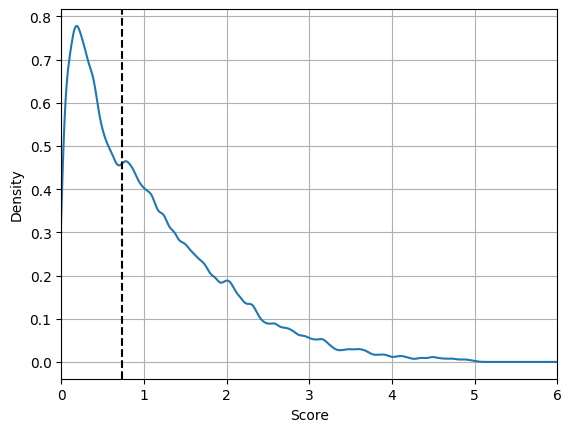

In [7]:
hic2_target_scores.query("chip_score>0 and chip_score < 5")["chip_score"].plot.density(bw_method=0.05)
cutoff=0.73
axis = pyplot.gca()
axis.axvline(cutoff, linestyle="dashed", color="black")
axis.grid(True)
axis.set_xlabel("Score")
axis.set_xlim(0, 6)
pyplot.show()

There are two peaks, where the second likely corresponds to true targets. A cutoff at 0.75 was chosen since this is just before the peak, meaning most true positives are found while minimizing unnecessary false positives.

In [8]:
hic2_targets = hic2_target_scores.query("chip_score > @cutoff").index.to_list()
print(f"Found {len(hic2_targets)} Hic2 targets")

Found 11607 Hic2 targets


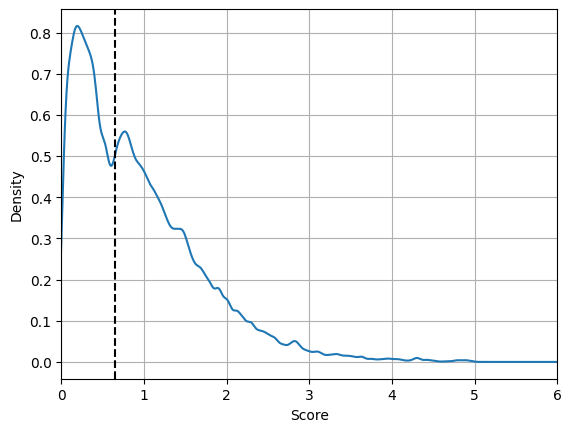

Found 12340 targets for Klf4 with Hic2 overexpression


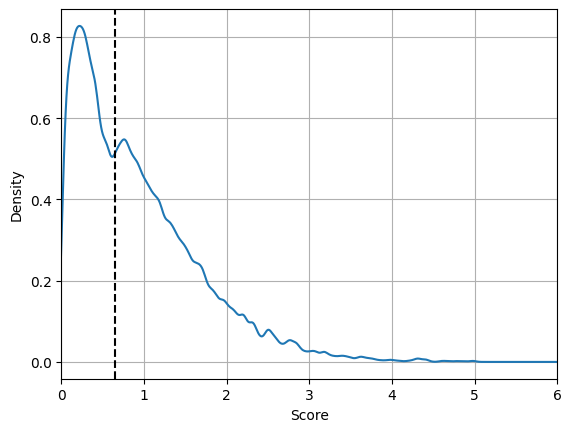

Found 12100 targets for Klf4 without Hic2 overexpression


In [9]:
# Find Klf4 targets with and without Hic2 overexpression

klf4_hic2_target_scores = closest_gene(klf4_hic2_peaks, annotation, use_center=True, max_distance=1000000)
klf4_hic2_target_scores.query("chip_score > 0 and chip_score < 5")["chip_score"].plot.density(bw_method=0.05)
cutoff=0.65
axis = pyplot.gca()
axis.axvline(cutoff, linestyle="dashed", color="black")
axis.grid(True)
axis.set_xlabel("Score")
axis.set_xlim(0, 6)
pyplot.show()
klf4_hic2_targets = klf4_hic2_target_scores.query("chip_score > @cutoff").index.to_list()
print(f"Found {len(klf4_hic2_targets)} targets for Klf4 with Hic2 overexpression")

klf4_control_target_scores = closest_gene(klf4_control_peaks, annotation, use_center=True, max_distance=1000000)
klf4_control_target_scores.query("chip_score > 0 and chip_score < 5")["chip_score"].plot.density(bw_method=0.05)
cutoff=0.65
axis = pyplot.gca()
axis.axvline(cutoff, linestyle="dashed", color="black")
axis.grid(True)
axis.set_xlabel("Score")
axis.set_xlim(0, 6)
pyplot.show()
klf4_control_targets = klf4_control_target_scores.query("chip_score > @cutoff").index.to_list()
print(f"Found {len(klf4_control_targets)} targets for Klf4 without Hic2 overexpression")

A cutoff of 0.7 is just before the second peak for both Klf4 experiments.

In [10]:
# Find overlapping binding sites
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
print(f"Found {len(klf4_targets)} overlapping Klf4 targets")

# Shared targets for Hic2 and Klf4
shared_targets = numpy.intersect1d(hic2_targets, klf4_hic2_targets)
print(f"Found {len(shared_targets)} shared targets")

Found 10717 overlapping Klf4 targets
Found 8842 shared targets


In [11]:
# Save targets to disk

base_name = "ChIP Sequencing Data/chipseq_targets"

hic2_target_scores.to_csv(f"{base_name}_hic2_scores.csv")
klf4_hic2_target_scores.to_csv(f"{base_name}_klf4_hic2_scores.csv")
klf4_control_target_scores.to_csv(f"{base_name}_klf4_control_scores.csv")

numpy.savetxt(f"{base_name}_hic2_targets.txt", hic2_targets, fmt="%s")
numpy.savetxt(f"{base_name}_klf4_hic2_targets.txt", klf4_hic2_targets, fmt="%s")
numpy.savetxt(f"{base_name}_klf4_control_targets.txt", klf4_control_targets, fmt="%s")